# Diversity Analysis: MS vs Healthy Cohort

This notebook demonstrates mirpy diversity analysis workflows with:
- VDJtools-style diversity metrics
- Hill diversity curves
- Rarefaction and sample coverage curves
- Cohort comparison (Healthy vs Multiple Sclerosis)

Dataset source: `isalgo/airr_benchmark` (`vdjtools/metadata_ms.txt`).
Target visuals include a Fig. 2-inspired diversity summary, rarefaction/coverage curves with confidence intervals, and Chao1 boxplot significance annotation.

In [2]:
# Set deterministic state and report environment versions for reproducibility
import importlib.metadata as _meta
import random
import sys

import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f'Python {sys.version.split()[0]}')
for _pkg in ['mirpy-lib', 'numpy', 'pandas', 'polars', 'scipy', 'matplotlib', 'seaborn']:
    try:
        print(f'  {_pkg}: {_meta.version(_pkg)}')
    except _meta.PackageNotFoundError:
        pass
print(f'SEED={SEED}')

Python 3.12.12
  mirpy-lib: 1.0.0
  numpy: 2.4.4
  pandas: 2.3.3
  polars: 1.39.3
  scipy: 1.17.1
  matplotlib: 3.10.9
  seaborn: 0.13.2
SEED=42


In [3]:
# Resolve repository root and import mirpy notebook asset helpers
from pathlib import Path

repo_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

import sys as _sys
if str(repo_root) not in _sys.path:
    _sys.path.insert(0, str(repo_root))

from mir.utils.notebook_assets import ensure_airr_benchmark

/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Download the required VDJtools benchmark subset and locate metadata
dataset_root = ensure_airr_benchmark(
    repo_root,
    allow_patterns=[
        'vdjtools/**',
        'vdjtools_lite/**',
    ],
)

meta_candidates = [
    dataset_root / 'vdjtools' / 'metadata_ms.txt',
    dataset_root / 'vdjtools_lite' / 'metadata_ms.txt',
]

metadata_path = next((p for p in meta_candidates if p.exists()), None)
if metadata_path is None:
    raise FileNotFoundError('metadata_ms.txt not found under vdjtools/ or vdjtools_lite/.')

print('dataset_root:', dataset_root)
print('metadata_path:', metadata_path)

Fetching 372 files: 100%|██████████| 372/372 [00:00<00:00, 2367.14it/s]

dataset_root: /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark
metadata_path: /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/vdjtools/metadata_ms.txt


In [8]:
# Load cohort metadata and normalize disease labels to Healthy/MS
import pandas as pd

meta = pd.read_csv(metadata_path, sep='\t')

file_col_candidates = ['file_name', 'file', 'filename', 'sample_file']
sample_col_candidates = ['sample_id', 'Run', 'run', 'sample', 'id']
group_col_candidates = [
    c for c in meta.columns if any(x in c.lower() for x in ['status', 'group', 'disease', 'condition', 'state'])
]

file_col = next((c for c in file_col_candidates if c in meta.columns), None)
sample_col = next((c for c in sample_col_candidates if c in meta.columns), None)
group_col = group_col_candidates[0] if group_col_candidates else None

if file_col is None or sample_col is None or group_col is None:
    raise ValueError(f'Could not infer metadata columns. Found columns: {list(meta.columns)}')

keep_cols = [sample_col, file_col, group_col]
for extra_col in ('age', 'sex'):
    if extra_col in meta.columns:
        keep_cols.append(extra_col)

meta = meta[keep_cols].copy()
rename_map = {sample_col: 'sample_id', file_col: 'file_name', group_col: 'raw_group'}
if 'age' in meta.columns:
    rename_map['age'] = 'age'
if 'sex' in meta.columns:
    rename_map['sex'] = 'sex'
meta = meta.rename(columns=rename_map)

# Re-label columns after the copy so the optional demographic fields stay available.
if 'age' in meta.columns:
    meta['age'] = pd.to_numeric(meta['age'], errors='coerce')
if 'sex' in meta.columns:
    meta['sex'] = meta['sex'].astype(str).str.strip()

def _normalize_group(value: str) -> str:
    s = str(value).strip().lower()
    if 'multiple' in s or s == 'ms' or 'ms' in s.replace('_', ' ').split():
        return 'MS'
    return 'Healthy'

meta['group'] = meta['raw_group'].map(_normalize_group)
meta = meta.sort_values(['group', 'sample_id', 'file_name']).reset_index(drop=True)
meta.head()

,sample_id,file_name,raw_group,age,sex,group
0,C1,A2-i129.txt.gz,C,11.0,M,Healthy
1,C10,A4-i194.txt.gz,C,20.0,M,Healthy
2,C11,A4-i195.txt.gz,C,21.0,F,Healthy
3,C2,A2-i131.txt.gz,C,9.0,M,Healthy
4,C3,A2-i132.txt.gz,C,6.0,F,Healthy


In [6]:
# Parse repertoires and compute per-sample diversity summaries and curves
from typing import Iterable

import polars as pl

from mir.common.parser import VDJtoolsParser
from mir.common.repertoire import LocusRepertoire

parser = VDJtoolsParser(sep='\t')

def _resolve_file(name: str) -> Path:
    p1 = dataset_root / 'vdjtools' / name
    p2 = dataset_root / 'vdjtools_lite' / name
    if p1.exists():
        return p1
    if p2.exists():
        return p2
    return dataset_root / name

def _adaptive_global_steps(min_n: int, max_n: int, n_steps: int = 14) -> list[int]:
    low = max(10, int(min_n))
    high = max(low, int(max_n))
    if low == high:
        return [low]
    raw = np.linspace(low, high, n_steps)
    return sorted({int(round(x)) for x in raw if int(round(x)) > 0})

sample_payloads: list[dict] = []
summary_rows: list[dict] = []
hill_rows: list[pl.DataFrame] = []
rare_rows: list[pl.DataFrame] = []

for row in meta.itertuples(index=False):
    sample_id = str(row.sample_id)
    group = str(row.group)
    age = float(getattr(row, 'age', np.nan)) if 'age' in meta.columns else np.nan
    file_path = _resolve_file(str(row.file_name))
    if not file_path.exists():
        continue

    try:
        clonotypes = parser.parse(str(file_path))
    except Exception:
        continue
    if not clonotypes:
        continue

    locus = str(getattr(clonotypes[0], 'locus', '') or 'TRB')
    rep = LocusRepertoire(clonotypes=clonotypes, locus=locus, repertoire_id=sample_id)

    summary = rep.diversity(count_field='duplicate_count')
    summary_rows.append(
        {
            'sample_id': sample_id,
            'group': group,
            'age': age,
            'locus': locus,
            **summary.to_dict(),
        }
    )

    hill_df = rep.hill_curve(count_field='duplicate_count')
    hill_rows.append(hill_df.with_columns(pl.lit(sample_id).alias('sample_id'), pl.lit(group).alias('group')))

    sample_payloads.append(
        {
            'sample_id': sample_id,
            'group': group,
            'rep': rep,
            'n': int(summary.abundance),
        }
    )

if sample_payloads:
    min_n = min(x['n'] for x in sample_payloads)
    max_n = max(x['n'] for x in sample_payloads)
    global_steps = _adaptive_global_steps(min_n, max_n, n_steps=14)
else:
    min_n, max_n, global_steps = 0, 0, []

for payload in sample_payloads:
    sample_id = payload['sample_id']
    group = payload['group']
    rep = payload['rep']
    n = payload['n']

    # Shared, evenly spaced steps across the cohort + exact sample depth.
    steps = sorted({m for m in global_steps if m > 0} | {n})
    rare_df = rep.rarefaction_curve(
        count_field='duplicate_count',
        m_steps=steps,
        include_exact=True,
    )
    rare_rows.append(rare_df.with_columns(pl.lit(sample_id).alias('sample_id'), pl.lit(group).alias('group')))

summary_df = pd.DataFrame(summary_rows)
if summary_df.empty:
    raise RuntimeError('No samples were parsed. Check metadata file_name values and parser compatibility.')
summary_df = summary_df.sort_values(['group', 'sample_id']).reset_index(drop=True)
hill_df = pl.concat(hill_rows) if hill_rows else pl.DataFrame()
rare_df = pl.concat(rare_rows) if rare_rows else pl.DataFrame()

print('Samples used:', len(summary_df))
print('Group counts:')
print(summary_df[['group']].value_counts())
print(f'Adaptive rarefaction step range: min_n={min_n}, max_n={max_n}, n_steps={len(global_steps)}')
if global_steps:
    print('First 5 global steps:', global_steps[:5])
    print('Last 5 global steps:', global_steps[-5:])
summary_df.head()

Samples used: 25
Group counts:
group  
MS         14
Healthy    11
Name: count, dtype: int64
Adaptive rarefaction step range: min_n=156825, max_n=1260200, n_steps=14
First 5 global steps: [156825, 241700, 326575, 411450, 496325]
Last 5 global steps: [920700, 1005575, 1090450, 1175325, 1260200]


,sample_id,group,age,locus,abundance,diversity,singletons,doubletons,expanded,hyperexpanded,chao1,gini_simpson,shannon
0,C1,Healthy,11.0,TRB,733696,540240,473315,47939,14,0,2.876771e+06,0.999833,12.623683
1,C10,Healthy,20.0,TRB,183043,125307,113865,7384,27,1,1.003108e+06,0.998167,10.735929
2,C11,Healthy,21.0,TRB,475026,337012,302848,25105,19,2,2.163599e+06,0.998536,11.718054
3,C2,Healthy,9.0,TRB,606357,381345,325027,35918,17,0,1.851907e+06,0.999775,11.972000
4,C3,Healthy,6.0,TRB,977264,763165,699291,42508,2,0,6.514973e+06,0.999983,13.142935


In [ ]:
# Render a polished donor summary table with per-group mean ± SD
from IPython.display import display

summary_table = summary_df[['sample_id', 'group', 'age', 'abundance', 'diversity', 'chao1', 'gini_simpson', 'shannon']].copy()
summary_table['age'] = summary_table['age'].round(1)
summary_table['abundance'] = summary_table['abundance'].map(lambda x: f'{int(x):,}')
summary_table['diversity'] = summary_table['diversity'].map(lambda x: f'{int(x):,}')
summary_table['chao1'] = summary_table['chao1'].map(lambda x: f'{x:,.0f}')
summary_table['gini_simpson'] = summary_table['gini_simpson'].map(lambda x: f'{x:.4f}')
summary_table['shannon'] = summary_table['shannon'].map(lambda x: f'{x:.2f}')

agg_rows = []
for group, group_df in summary_df.groupby('group', sort=True):
    agg_rows.append(
        {
            'sample_id': f'{group} mean ± sd',
            'group': group,
            'age': f"{group_df['age'].mean():.1f} ± {group_df['age'].std(ddof=1):.1f}",
            'abundance': f"{group_df['abundance'].mean():,.0f} ± {group_df['abundance'].std(ddof=1):,.0f}",
            'diversity': f"{group_df['diversity'].mean():,.0f} ± {group_df['diversity'].std(ddof=1):,.0f}",
            'chao1': f"{group_df['chao1'].mean():,.0f} ± {group_df['chao1'].std(ddof=1):,.0f}",
            'gini_simpson': f"{group_df['gini_simpson'].mean():.4f} ± {group_df['gini_simpson'].std(ddof=1):.4f}",
            'shannon': f"{group_df['shannon'].mean():.2f} ± {group_df['shannon'].std(ddof=1):.2f}",
        }
    )

summary_display = pd.concat([summary_table, pd.DataFrame(agg_rows)], ignore_index=True)
summary_display = summary_display.sort_values(['group', 'sample_id'], kind='stable').reset_index(drop=True)

styler = (
    summary_display.style
    .set_caption('Donor diversity summary: ages, abundance, and diversity with per-group mean ± SD')
    .hide(axis='index')
    .format(na_rep='')
    .set_properties(**{'border-color': '#d9d9d9', 'padding': '0.35rem 0.5rem'})
    .set_table_styles(
        [
            {'selector': 'caption', 'props': [('font-weight', '700'), ('font-size', '1.05rem'), ('text-align', 'left'), ('padding-bottom', '0.35rem')]},
            {'selector': 'th', 'props': [('background-color', '#f6f6f6'), ('font-weight', '700')]},
            {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#fcfcfc')]},
        ]
    )
    .background_gradient(subset=['age', 'abundance', 'diversity', 'chao1', 'gini_simpson', 'shannon'], cmap='YlGnBu')
)

display(styler)
print('Table rows:', len(summary_display))
print('Per-group mean ± SD rows appended at bottom.')

In [9]:
# Build a cohort demographics summary with age range and sex counts
from IPython.display import display

if 'sex' not in meta.columns:
    raise RuntimeError("Expected a 'sex' column in the cohort metadata.")

meta_demographics = meta.copy()
meta_demographics['sex'] = meta_demographics['sex'].fillna('').astype(str).str.strip().str.upper()
meta_demographics['sex'] = meta_demographics['sex'].replace({'FEMALE': 'F', 'MALE': 'M'})
meta_demographics['cohort_label'] = meta_demographics['group']
meta_demographics['note'] = ''
meta_demographics.loc[meta_demographics['sample_id'].astype(str).str.upper() == 'M14', 'note'] = 'post-HSCT'

cohort_rows = []
for group, group_df in meta_demographics.groupby('cohort_label', sort=True):
    age_series = pd.to_numeric(group_df['age'], errors='coerce') if 'age' in group_df.columns else pd.Series(dtype=float)
    sex_counts = group_df['sex'].value_counts(dropna=False)
    cohort_rows.append(
        {
            'Cohort': group,
            'Samples': len(group_df),
            'Age range': (
                f"{int(age_series.min())}–{int(age_series.max())}" if age_series.notna().any() else ''
            ),
            'Age mean ± sd': (
                f"{age_series.mean():.1f} ± {age_series.std(ddof=1):.1f}" if age_series.notna().sum() > 1 else ''
            ),
            'Sex F': int(sex_counts.get('F', 0)),
            'Sex M': int(sex_counts.get('M', 0)),
            'Sex other/NA': int(len(group_df) - int(sex_counts.get('F', 0)) - int(sex_counts.get('M', 0))),
            'Post-HSCT note': 'M14' if (group_df['sample_id'].astype(str).str.upper() == 'M14').any() else '',
        }
    )

cohort_df = pd.DataFrame(cohort_rows)
cohort_display = cohort_df.copy()

cohort_styler = (
    cohort_display.style
    .set_caption('Cohort demographics summary: age range and sex counts')
    .hide(axis='index')
    .set_properties(**{'border-color': '#d9d9d9', 'padding': '0.35rem 0.5rem'})
    .set_table_styles(
        [
            {'selector': 'caption', 'props': [('font-weight', '700'), ('font-size', '1.05rem'), ('text-align', 'left'), ('padding-bottom', '0.35rem')]},
            {'selector': 'th', 'props': [('background-color', '#f6f6f6'), ('font-weight', '700')]},
            {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#fcfcfc')]},
        ]
    )
)

display(cohort_styler)
print('M14 is marked as a post-HSCT MS sample in the note column.')

Cohort,Samples,Age range,Age mean ± sd,Sex F,Sex M,Sex other/NA,Post-HSCT note
Healthy,11,6–25,16.4 ± 6.6,4,7,0,
MS,14,6–15,12.8 ± 2.9,14,0,0,


M14 is marked as a post-HSCT MS sample in the note column.


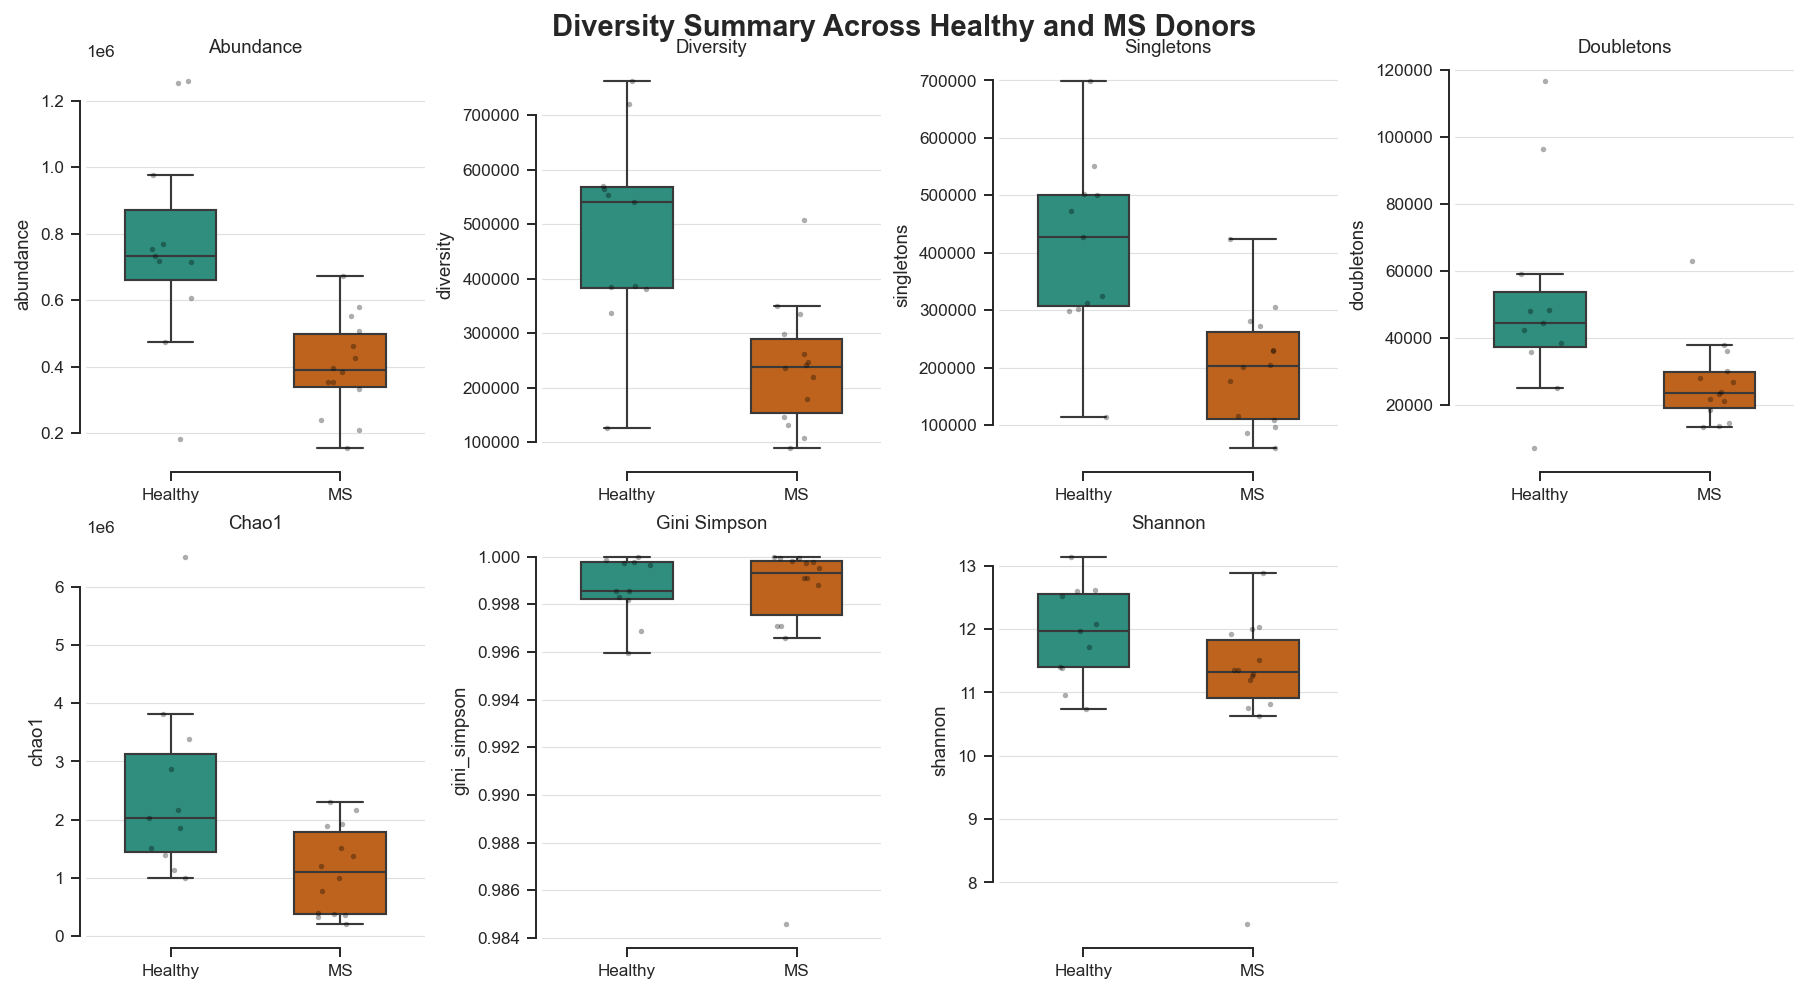

In [10]:
# Build a Fig. 2-inspired multi-panel diversity summary figure
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Publication-style typography and panel aesthetics inspired by journal figure conventions.
mpl.rcParams.update(
    {
        'font.family': 'serif',
        'font.serif': ['STIX Two Text', 'Times New Roman', 'DejaVu Serif'],
        'mathtext.fontset': 'stix',
        'axes.linewidth': 1.0,
        'axes.titlesize': 13,
        'axes.labelsize': 11,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 10,
        'figure.dpi': 140,
        'savefig.dpi': 300,
    }
)

sns.set_theme(style='ticks', context='paper')
metrics = ['abundance', 'diversity', 'singletons', 'doubletons', 'chao1', 'gini_simpson', 'shannon']
palette = {'Healthy': '#1f9e89', 'MS': '#d95f02'}

fig, axes = plt.subplots(2, 4, figsize=(12.8, 6.8), constrained_layout=True)
axes = axes.ravel()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(
        data=summary_df,
        x='group',
        y=metric,
        hue='group',
        order=['Healthy', 'MS'],
        hue_order=['Healthy', 'MS'],
        palette=palette,
        ax=ax,
        width=0.54,
        linewidth=1.1,
        fliersize=0,
        legend=False,
    )
    sns.stripplot(
        data=summary_df,
        x='group',
        y=metric,
        order=['Healthy', 'MS'],
        color='black',
        alpha=0.32,
        size=2.8,
        jitter=0.14,
        ax=ax,
    )
    ax.set_title(metric.replace('_', ' ').title(), pad=5)
    ax.set_xlabel('')
    ax.grid(axis='y', color='#d9d9d9', linewidth=0.6, alpha=0.8)
    sns.despine(ax=ax, offset=3, trim=True)

axes[-1].axis('off')
fig.suptitle('Diversity Summary Across Healthy and MS Donors', y=1.02, fontsize=15, fontweight='bold')
plt.show()

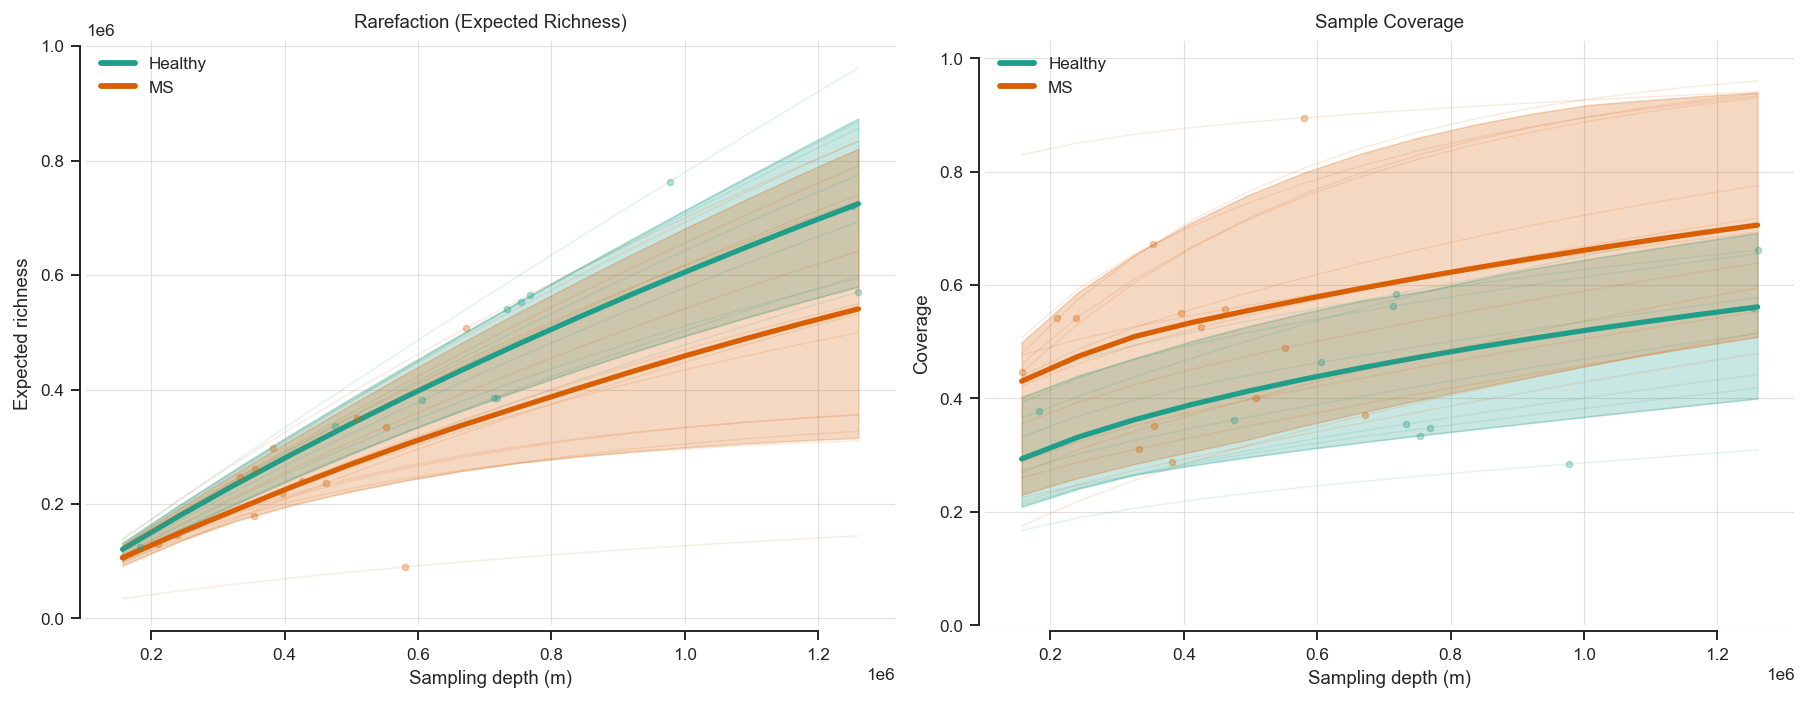

In [11]:
# Plot rarefaction and sample coverage curves with confidence intervals by cohort
from matplotlib.lines import Line2D

if rare_df.height == 0:
    raise RuntimeError('No rarefaction results were generated.')

rare_pd = rare_df.to_pandas().sort_values(['group', 'sample_id', 'm'])
common_m = sorted(set(global_steps)) if 'global_steps' in globals() else sorted(rare_pd['m'].unique())

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.9), constrained_layout=True)

for group in ['Healthy', 'MS']:
    sub = rare_pd[rare_pd['group'] == group].copy()
    if sub.empty:
        continue
    color = palette[group]

    # Light donor trajectories on common steps only to keep curves smooth.
    for sid, ssub in sub.groupby('sample_id'):
        scommon = ssub[ssub['m'].isin(common_m)].sort_values('m')
        if scommon.empty:
            continue
        axes[0].plot(scommon['m'], scommon['s_est'], color=color, linewidth=0.8, alpha=0.12)
        axes[1].plot(scommon['m'], scommon['coverage'], color=color, linewidth=0.8, alpha=0.12)

        # Mark exact sample depth as a small point.
        sexact = ssub[ssub['m'] == ssub['n']]
        if not sexact.empty:
            axes[0].scatter(sexact['m'], sexact['s_est'], color=color, s=10, alpha=0.3, zorder=3)
            axes[1].scatter(sexact['m'], sexact['coverage'], color=color, s=10, alpha=0.3, zorder=3)

    ssub_common = sub[sub['m'].isin(common_m)]
    agg = ssub_common.groupby('m', as_index=False).agg(
        s_med=('s_est', 'median'),
        s_lwr=('s_est', lambda x: np.quantile(x, 0.1)),
        s_upr=('s_est', lambda x: np.quantile(x, 0.9)),
        coverage_med=('coverage', 'median'),
        coverage_lwr=('coverage', lambda x: np.quantile(x, 0.1)),
        coverage_upr=('coverage', lambda x: np.quantile(x, 0.9)),
    )

    axes[0].plot(agg['m'], agg['s_med'], color=color, linewidth=2.7)
    axes[0].fill_between(agg['m'], agg['s_lwr'], agg['s_upr'], color=color, alpha=0.24)

    axes[1].plot(agg['m'], agg['coverage_med'], color=color, linewidth=2.7)
    axes[1].fill_between(agg['m'], agg['coverage_lwr'], agg['coverage_upr'], color=color, alpha=0.24)

axes[0].set_title('Rarefaction (Expected Richness)', pad=7)
axes[0].set_xlabel('Sampling depth (m)')
axes[0].set_ylabel('Expected richness')
axes[0].grid(axis='both', color='#d9d9d9', linewidth=0.6, alpha=0.8)

axes[1].set_title('Sample Coverage', pad=7)
axes[1].set_xlabel('Sampling depth (m)')
axes[1].set_ylabel('Coverage')
axes[1].set_ylim(0, 1.03)
axes[1].grid(axis='both', color='#d9d9d9', linewidth=0.6, alpha=0.8)

legend = [
    Line2D([0], [0], color=palette['Healthy'], lw=3, label='Healthy'),
    Line2D([0], [0], color=palette['MS'], lw=3, label='MS'),
]
axes[0].legend(handles=legend, frameon=False, loc='best')
axes[1].legend(handles=legend, frameon=False, loc='best')

for ax in axes:
    sns.despine(ax=ax, offset=3, trim=True)

plt.show()

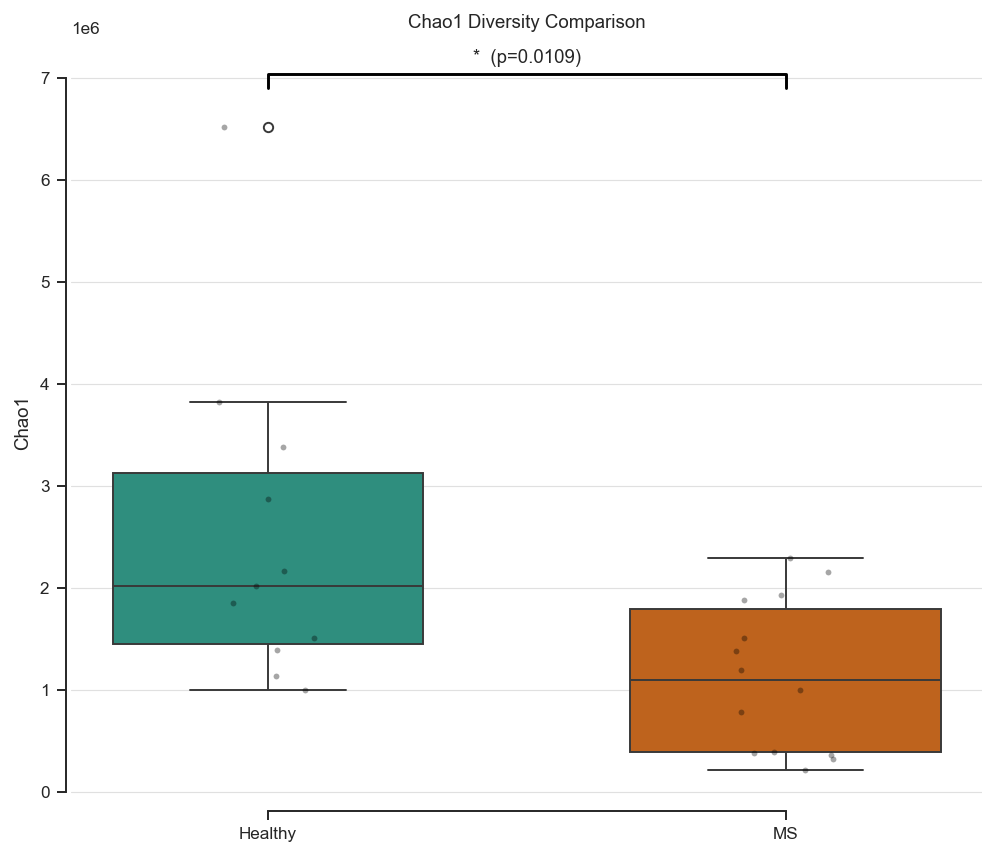

Mann-Whitney U statistic: 124.0
p-value: 0.01090784295903633


In [12]:
# Compare Chao1 distributions and annotate significance with p-value stars
from scipy.stats import mannwhitneyu

healthy = summary_df.loc[summary_df['group'] == 'Healthy', 'chao1'].to_numpy()
ms = summary_df.loc[summary_df['group'] == 'MS', 'chao1'].to_numpy()

if len(healthy) > 0 and len(ms) > 0:
    stat, p_value = mannwhitneyu(healthy, ms, alternative='two-sided')
else:
    stat, p_value = np.nan, np.nan

def p_to_star(p: float) -> str:
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'

star = p_to_star(float(p_value))

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
sns.boxplot(
    data=summary_df,
    x='group',
    y='chao1',
    hue='group',
    order=['Healthy', 'MS'],
    hue_order=['Healthy', 'MS'],
    palette=palette,
    ax=ax,
    width=0.6,
    legend=False,
)
sns.stripplot(data=summary_df, x='group', y='chao1', order=['Healthy', 'MS'], color='black', alpha=0.35, size=3, ax=ax)

ymax = float(summary_df['chao1'].max()) if len(summary_df) else 1.0
y = ymax * 1.08
ax.plot([0, 0, 1, 1], [y * 0.98, y, y, y * 0.98], color='black', linewidth=1.5)
ax.text(0.5, y * 1.01, f'{star}  (p={p_value:.3g})', ha='center', va='bottom')
ax.set_title('Chao1 Diversity Comparison')
ax.set_xlabel('')
ax.set_ylabel('Chao1')
ax.grid(axis='y', color='#d9d9d9', linewidth=0.6, alpha=0.8)
sns.despine(ax=ax, offset=3, trim=True)
plt.show()

print('Mann-Whitney U statistic:', stat)
print('p-value:', p_value)

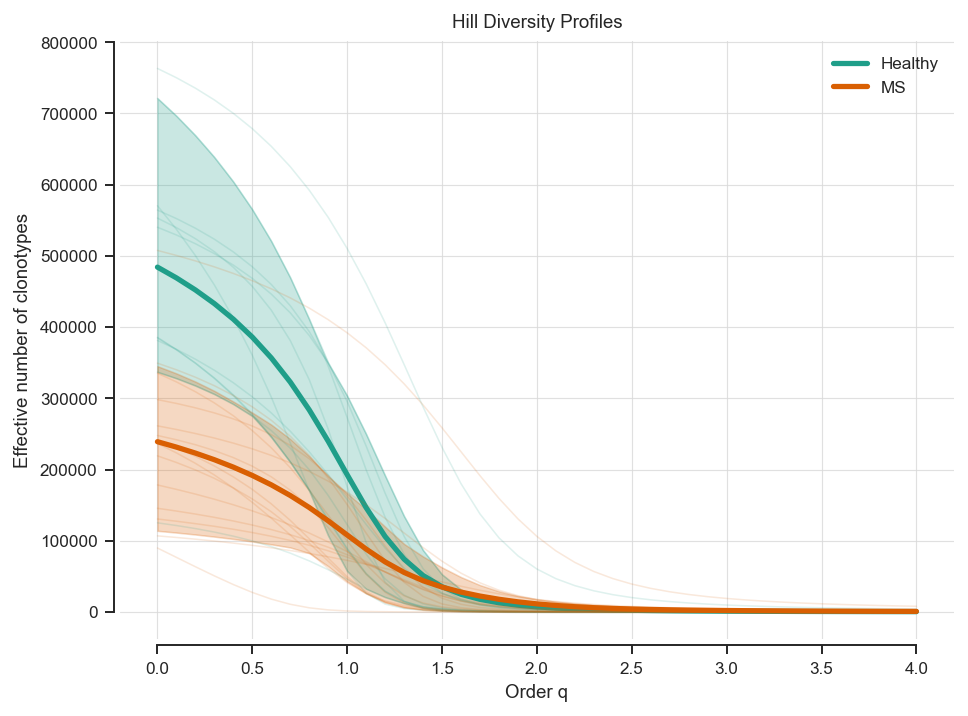

In [13]:
# Plot Hill diversity profiles by cohort
if hill_df.height == 0:
    raise RuntimeError('No Hill curve results were generated.')

hill_pd = hill_df.to_pandas().sort_values(['group', 'sample_id', 'q'])

fig, ax = plt.subplots(figsize=(6.8, 5.0), constrained_layout=True)

for group in ['Healthy', 'MS']:
    sub = hill_pd[hill_pd['group'] == group].copy()
    if sub.empty:
        continue
    color = palette[group]

    # Light donor-level trajectories + bold cohort mean with quantile band.
    for sid, ssub in sub.groupby('sample_id'):
        ax.plot(ssub['q'], ssub['hill'], color=color, linewidth=0.8, alpha=0.14)

    agg = sub.groupby('q', as_index=False).agg(
        hill_mean=('hill', 'mean'),
        hill_lwr=('hill', lambda x: np.quantile(x, 0.1)),
        hill_upr=('hill', lambda x: np.quantile(x, 0.9)),
    )
    ax.plot(agg['q'], agg['hill_mean'], color=color, linewidth=2.7, label=group)
    ax.fill_between(agg['q'], agg['hill_lwr'], agg['hill_upr'], color=color, alpha=0.24)

ax.set_title('Hill Diversity Profiles', pad=7)
ax.set_xlabel('Order q')
ax.set_ylabel('Effective number of clonotypes')
ax.grid(axis='both', color='#d9d9d9', linewidth=0.6, alpha=0.8)
ax.legend(frameon=False, loc='best')
sns.despine(ax=ax, offset=3, trim=True)
plt.show()

## Notes

- The cohort labels are normalized to `Healthy` and `MS` from metadata text values.
- The donor summary table includes age, abundance, diversity, Chao1, Gini-Simpson, and Shannon, with per-group mean ± SD rows.
- A cohort-level demographics table above summarizes age range and sex counts for each cohort.
- The source MS metadata includes a post-HSCT sample (M14); treat it as a special case when making cohort-level comparisons.
- Diversity summaries use `duplicate_count` by default in this notebook.
- For UMI-based diversity, pass `count_field='umi_count'` to `diversity`, `hill_curve`, and `rarefaction_curve`.
- For paired/single-cell objects, mirpy defaults to `count_field='barcode_count'`.